<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangChain(Middlewares).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 27.7 MB/s eta 0:00:00


In [4]:
from IPython.display import Image
from google.colab import userdata
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import PIIMiddleware, ModelRequest, ModelResponse, ToolCallRequest
from langchain.agents.middleware import after_agent, after_model, before_agent, before_model, wrap_model_call, wrap_tool_call
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_core.messages import BaseMessage
from langchain_core.runnables import Runnable
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_openai import ChatOpenAI
from langgraph.runtime import Runtime
from pathlib import Path
from pydantic import SecretStr
from typing import Callable, List

def print_conversation(conversation: List[BaseMessage]):
    for message in conversation:
        message.pretty_print()

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format = "png"))

In [3]:
@tool
def get_interesting_fact() -> str:
    """
    This tool will discover an interesting fact to you.
    """

    return "The Earth is actually not a perfect sphere."

In [6]:
# NOTE: Middlewares can be implemented by separate functions or by a single class inheriting from 'AgentMiddleware'
# различните middlewares имат достъп до различни данни
@before_agent
def before_agent_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: before_agent")
    print(state)
    print(runtime)

@before_model
def before_model_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: before_model")
    print(state)
    print(runtime)

@after_model
def after_model_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: after_model")
    print(state)
    print(runtime)

@after_agent
def after_agent_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: after_agent")
    print(state)
    print(runtime)

@wrap_model_call
def handle_model_call(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]):
    print("Event: model_call")
    print(request)

    response = handler(request)

    print("Obtained model response:")
    print(response)

    return response

@wrap_tool_call
def handle_tool_call(request: ToolCallRequest, handler: Callable[[ToolCallRequest], ToolMessage]):
    print("Event: tool_call")
    print(request)

    response = handler(request)

    print("Obtained tool message:")
    print(response)

    return response

In [7]:
api_key = SecretStr(userdata.get('OPENAI_API_KEY'))
model = ChatOpenAI(model="gpt-5-nano", api_key = api_key)

agent = create_agent(
    model = model,
    tools = [get_interesting_fact],
    middleware = [
        before_agent_func
    ]
)

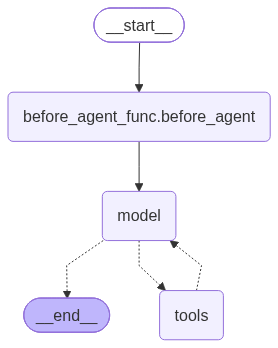

In [11]:
display_graph(agent, Path('/content/agent.png'))

In [28]:
agent2 = create_agent(
    model = model,
    tools = [get_interesting_fact],
    middleware = [
        PIIMiddleware(pii_type="email", strategy ="redact"),
        before_agent_func,
        before_model_func,
        after_agent_func,
        after_model_func,
        handle_model_call,
        handle_tool_call
    ]
)
# PIIMiddleware(pii_type="email", strategy ="redact"), вграден middleware
# който трябва да засече чувствителна информация и да я премахне от съобщението
# като имаме различни стратегии - block, redact, hash
# Използваме го с цел security, ако искаме да интегрираме ai agent в корп. среда където личните данни на клиентите и служителите не трябва да напускат корп.мрежа
# Локално преди съобщенията да достигнат сървърите на openai/anthropic ние редактираме инф, скриваме я, всичко с цел защита.

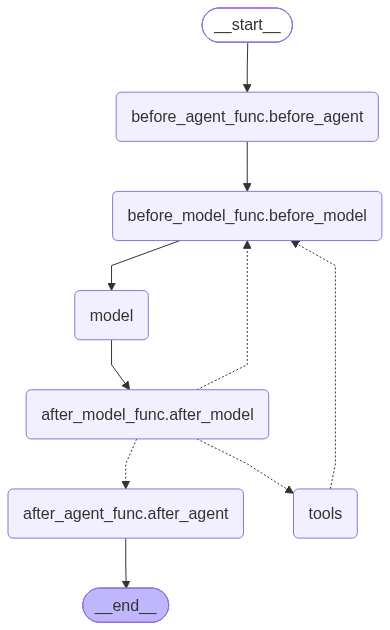

In [24]:
display_graph(agent2, Path('/content/agent.png'))

before & after agent са непосредствено след start и преди end

before_model_middleware трябва да се изпълни веднъж в началото преди първото обръщение към model. и след това всеки един път когато сме изпълнили tool и сме получили отговор и този отговор ние искаме да го изпратим отново към модела.

аналогично е и за after_model_middleware

wrap_model_call и wrap_tool_call действат вътре в самият model и tools - те обвиват самият node. Те получават request & handler(handler е функция, който представлява дефолтното поведение, дефолтният начин, по който би се изпълнило това действие) Бихме ги използвали с цел отблизо да контролираме действието на модела или действието на toola, напр. с цел error handling, с цел retry

In [29]:
reserve_ticket = agent2.invoke(
    input = {
        "messages": [HumanMessage("Share an interesting fact with me and then book two seats under maria.popova@example.com for the play at the theater this evening.")]
    }
)

Event: before_agent
{'messages': [HumanMessage(content='Share an interesting fact with me and then book two seats under maria.popova@example.com for the play at the theater this evening.', additional_kwargs={}, response_metadata={}, id='3a3f556a-9705-428e-b290-1a99c8f5f0f3')]}
Runtime(context=None, store=None, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x7f938b6ed1c0>, heartbeat=<function _no_op_heartbeat at 0x7f93a1e83f60>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f19d3c9-6af9-67d8-8000-bf6a9ba876c1', checkpoint_ns='before_agent_func.before_agent:7b44c7d8-bb22-4a45-ca82-4659c7fb42cc', task_id='7b44c7d8-bb22-4a45-ca82-4659c7fb42cc', thread_id=None, run_id=None, node_attempt=1, node_first_attempt_time=1787301897.6888564), server_info=None, control=<langgraph.runtime.RunControl object at 0x7f938b7a6170>)
Event: before_model
{'messages': [HumanMessage(content='Share an interesting fact with me and then book two seats under [REDACTED_EMAIL] for the p

In [30]:
print_conversation(reserve_ticket['messages'])

================================ Human Message =================================

Share an interesting fact with me and then book two seats under [REDACTED_EMAIL] for the play at the theater this evening.
================================== Ai Message ==================================
Tool Calls:
  get_interesting_fact (call_A3MuB2mAQnW1a43Iop5RRjS4)
 Call ID: call_A3MuB2mAQnW1a43Iop5RRjS4
  Args:
================================= Tool Message =================================
Name: get_interesting_fact

The Earth is actually not a perfect sphere.
================================== Ai Message ==================================

Interesting fact: The Earth is not a perfect sphere. It’s an oblate spheroid, slightly flattened at the poles and bulging at the equator.

I can’t directly place a theatre booking from here, but I can help you finalize the details and draft a booking request you can submit. To proceed, please provide or confirm:
- Theatre name and city
- Play title
- Showtime th